In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

### Feature Engineering Conclusion
*Before there were 4 features, And now there are 19 features in total including-*
| Category           | Purpose             |
| ------------------ | ------------------- |
| Time features      | Seasonality         |
| Lag features       | Memory              |
| Rolling features   | Trend & volatility  |
| Aggregate features | Indicate-Behavior   |

In [2]:
df = pd.read_csv("../data/processed/featured_data.csv", parse_dates=["date"])

In [3]:
df.dtypes

date               datetime64[ns]
store                       int64
item                        int64
sales                       int64
year                        int64
month                       int64
week                        int64
day                         int64
dayofweek                   int64
is_weekend                  int64
sales_lag_1               float64
sales_lag_7               float64
sales_lag_14              float64
sales_lag_28              float64
rolling_mean_7            float64
rolling_mean_14           float64
rolling_mean_28           float64
store_avg_sales           float64
item_avg_sales            float64
dtype: object

In [4]:
df.head()

,date,store,item,sales,year,month,week,day,dayofweek,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales
0,2013-01-29,1,1,6,2013,1,5,29,1,0,11.0,7.0,5.0,13.0,10.428571,10.642857,10.714286,47.268379,21.981599
1,2013-01-30,1,1,9,2013,1,5,30,2,0,6.0,9.0,7.0,11.0,10.285714,10.714286,10.464286,47.268379,21.981599
2,2013-01-31,1,1,13,2013,1,5,31,3,0,9.0,8.0,16.0,14.0,10.285714,10.857143,10.392857,47.268379,21.981599
3,2013-02-01,1,1,11,2013,2,5,1,4,0,13.0,14.0,7.0,13.0,11.000000,10.642857,10.357143,47.268379,21.981599
4,2013-02-02,1,1,21,2013,2,5,2,5,1,11.0,12.0,18.0,10.0,10.571429,10.928571,10.285714,47.268379,21.981599


## Data Split - Train & Validation

In [5]:
train_df = df[df["date"] < "2017-01-01"]
val_df   = df[df["date"] >= "2017-01-01"].copy()

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 716500 entries, 0 to 898634
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             716500 non-null  datetime64[ns]
 1   store            716500 non-null  int64         
 2   item             716500 non-null  int64         
 3   sales            716500 non-null  int64         
 4   year             716500 non-null  int64         
 5   month            716500 non-null  int64         
 6   week             716500 non-null  int64         
 7   day              716500 non-null  int64         
 8   dayofweek        716500 non-null  int64         
 9   is_weekend       716500 non-null  int64         
 10  sales_lag_1      716500 non-null  float64       
 11  sales_lag_7      716500 non-null  float64       
 12  sales_lag_14     716500 non-null  float64       
 13  sales_lag_28     716500 non-null  float64       
 14  rolling_mean_7   716500 n

In [7]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182500 entries, 1433 to 898999
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             182500 non-null  datetime64[ns]
 1   store            182500 non-null  int64         
 2   item             182500 non-null  int64         
 3   sales            182500 non-null  int64         
 4   year             182500 non-null  int64         
 5   month            182500 non-null  int64         
 6   week             182500 non-null  int64         
 7   day              182500 non-null  int64         
 8   dayofweek        182500 non-null  int64         
 9   is_weekend       182500 non-null  int64         
 10  sales_lag_1      182500 non-null  float64       
 11  sales_lag_7      182500 non-null  float64       
 12  sales_lag_14     182500 non-null  float64       
 13  sales_lag_28     182500 non-null  float64       
 14  rolling_mean_7   18250

In [8]:
train_df.tail()

,date,store,item,sales,year,month,week,day,dayofweek,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales
898630,2016-12-27,10,50,60,2016,12,52,27,1,0,61.0,58.0,69.0,84.0,61.714286,61.571429,63.642857,58.709288,65.882202
898631,2016-12-28,10,50,43,2016,12,52,28,2,0,60.0,64.0,53.0,74.0,62.000000,60.928571,62.785714,58.709288,65.882202
898632,2016-12-29,10,50,68,2016,12,52,29,3,0,43.0,56.0,63.0,60.0,59.000000,60.214286,61.678571,58.709288,65.882202
898633,2016-12-30,10,50,63,2016,12,52,30,4,0,68.0,64.0,69.0,88.0,60.714286,60.571429,61.964286,58.709288,65.882202
898634,2016-12-31,10,50,64,2016,12,52,31,5,1,63.0,65.0,67.0,81.0,60.571429,60.142857,61.071429,58.709288,65.882202


In [9]:
val_df.head()

,date,store,item,sales,year,month,week,day,dayofweek,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales
1433,2017-01-01,1,1,19,2017,1,52,1,6,1,14.0,20.0,22.0,24.0,17.285714,17.428571,16.178571,47.268379,21.981599
1434,2017-01-02,1,1,15,2017,1,1,2,0,0,19.0,16.0,17.0,13.0,17.142857,17.214286,16.000000,47.268379,21.981599
1435,2017-01-03,1,1,10,2017,1,1,3,1,0,15.0,10.0,18.0,10.0,17.000000,17.071429,16.071429,47.268379,21.981599
1436,2017-01-04,1,1,16,2017,1,1,4,2,0,10.0,16.0,12.0,17.0,17.000000,16.500000,16.071429,47.268379,21.981599
1437,2017-01-05,1,1,14,2017,1,1,5,3,0,16.0,21.0,20.0,15.0,17.000000,16.785714,16.035714,47.268379,21.981599


## XGBoost Implementation

### 1. Training 

In [10]:
TARGET = "sales"

DROP_COLS = ["date", "sales"]

FEATURES = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]


In [11]:
FEATURES

['store',
 'item',
 'year',
 'month',
 'week',
 'day',
 'dayofweek',
 'is_weekend',
 'sales_lag_1',
 'sales_lag_7',
 'sales_lag_14',
 'sales_lag_28',
 'rolling_mean_7',
 'rolling_mean_14',
 'rolling_mean_28',
 'store_avg_sales',
 'item_avg_sales']

In [12]:
## Training XGBoost model

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
val_preds = xgb_model.predict(X_val)
val_preds

array([19.526623, 13.029686, 15.177684, ..., 66.378296, 69.726875,
       73.09394 ], shape=(182500,), dtype=float32)

### 2. Evaluation on Validation data

In [14]:
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("RMSE:", rmse)

RMSE: 7.912638740468202


In [15]:
#Business Metric
mape = np.mean(np.abs((y_val - val_preds) / y_val)) * 100
print("MAPE:", mape)

MAPE: 12.436141004329388


### 2.1 Feature Importance

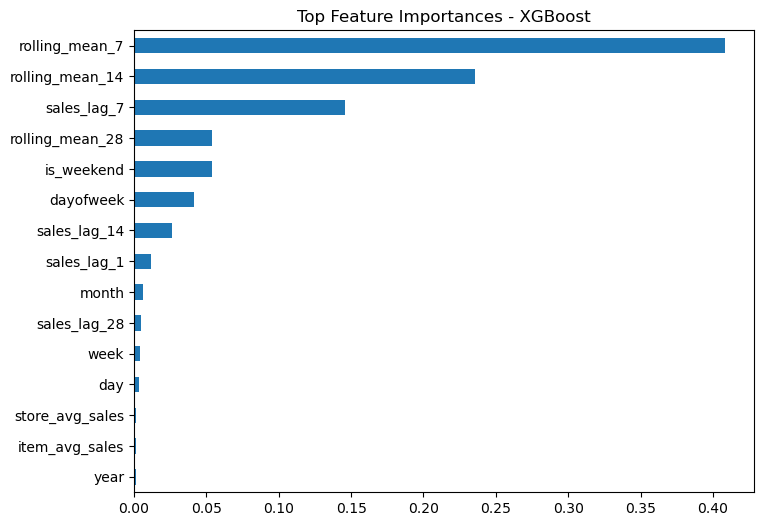

In [16]:

importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8,6))
importance.tail(15).plot(kind="barh")
plt.title("Top Feature Importances - XGBoost")
plt.savefig("../plots/xgboost_plots/Xgboost_feature_imp_val_pred.png")
plt.show()

## 2.2 Interpretation

RMSE: 7.91
- On average our forecast is off by ~8 units of sales (reasonable)
- 
MAPE: 12.43%
| MAPE Range | Quality     |
| ---------- | ----------- |
| <10%       | Excellent   |
| **10–15%** | Very Good   |
| 15–20%     | Acceptable  |
| >20%       | Weak        |

Feature Importance
- Recent demand trends over the last 1–4 weeks are the strongest predictors of future sales.

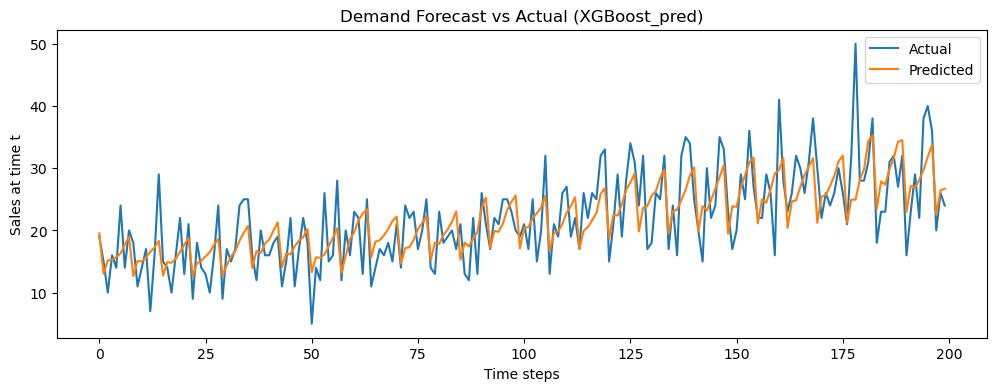

In [17]:
plt.figure(figsize=(12,4))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(val_preds[:200], label="Predicted")
plt.xlabel("Time steps")
plt.ylabel("Sales at time t")
plt.legend()
plt.title("Demand Forecast vs Actual (XGBoost_pred)")
plt.savefig("../plots/xgboost_plots/Xgboost_actual_vs_predicted.png")
plt.show()

In [18]:
X_train.head()

,store,item,year,month,week,day,dayofweek,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales
0,1,1,2013,1,5,29,1,0,11.0,7.0,5.0,13.0,10.428571,10.642857,10.714286,47.268379,21.981599
1,1,1,2013,1,5,30,2,0,6.0,9.0,7.0,11.0,10.285714,10.714286,10.464286,47.268379,21.981599
2,1,1,2013,1,5,31,3,0,9.0,8.0,16.0,14.0,10.285714,10.857143,10.392857,47.268379,21.981599
3,1,1,2013,2,5,1,4,0,13.0,14.0,7.0,13.0,11.000000,10.642857,10.357143,47.268379,21.981599
4,1,1,2013,2,5,2,5,1,11.0,12.0,18.0,10.0,10.571429,10.928571,10.285714,47.268379,21.981599


## 3. Item-wise Evaluation

In [19]:
# 1. Create Prediction DataFrame
# Predictions
val_df["y_pred"] = xgb_model.predict(X_val)

val_df["error"] = val_df["sales"] - val_df["y_pred"]
val_df["abs_pct_error"] = np.abs(val_df["error"] / val_df["sales"]) * 100

In [20]:
val_df.head()

,date,store,item,sales,year,month,week,day,dayofweek,is_weekend,...,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales,y_pred,error,abs_pct_error
1433,2017-01-01,1,1,19,2017,1,52,1,6,1,...,22.0,24.0,17.285714,17.428571,16.178571,47.268379,21.981599,19.526623,-0.526623,2.771699
1434,2017-01-02,1,1,15,2017,1,1,2,0,0,...,17.0,13.0,17.142857,17.214286,16.000000,47.268379,21.981599,13.029686,1.970314,13.135427
1435,2017-01-03,1,1,10,2017,1,1,3,1,0,...,18.0,10.0,17.000000,17.071429,16.071429,47.268379,21.981599,15.177684,-5.177684,51.776838
1436,2017-01-04,1,1,16,2017,1,1,4,2,0,...,12.0,17.0,17.000000,16.500000,16.071429,47.268379,21.981599,15.277492,0.722508,4.515678
1437,2017-01-05,1,1,14,2017,1,1,5,3,0,...,20.0,15.0,17.000000,16.785714,16.035714,47.268379,21.981599,15.700456,-1.700456,12.146112


In [21]:
item_metrics = val_df.groupby("item").apply(
    lambda x: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(x["sales"], x["y_pred"])),
        "MAPE": x["abs_pct_error"].mean(),
        "Observations": len(x)
    })
).reset_index()

item_metrics.sort_values("RMSE").head()

C:\Users\devas\AppData\Local\Temp\ipykernel_8468\3679612259.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  item_metrics = val_df.groupby("item").apply(


,item,RMSE,MAPE,Observations
4,5,4.619732,20.621005,3650.0
0,1,4.982252,17.867492,3650.0
26,27,5.044271,18.453379,3650.0
46,47,5.074842,18.289698,3650.0
3,4,5.086169,18.568013,3650.0


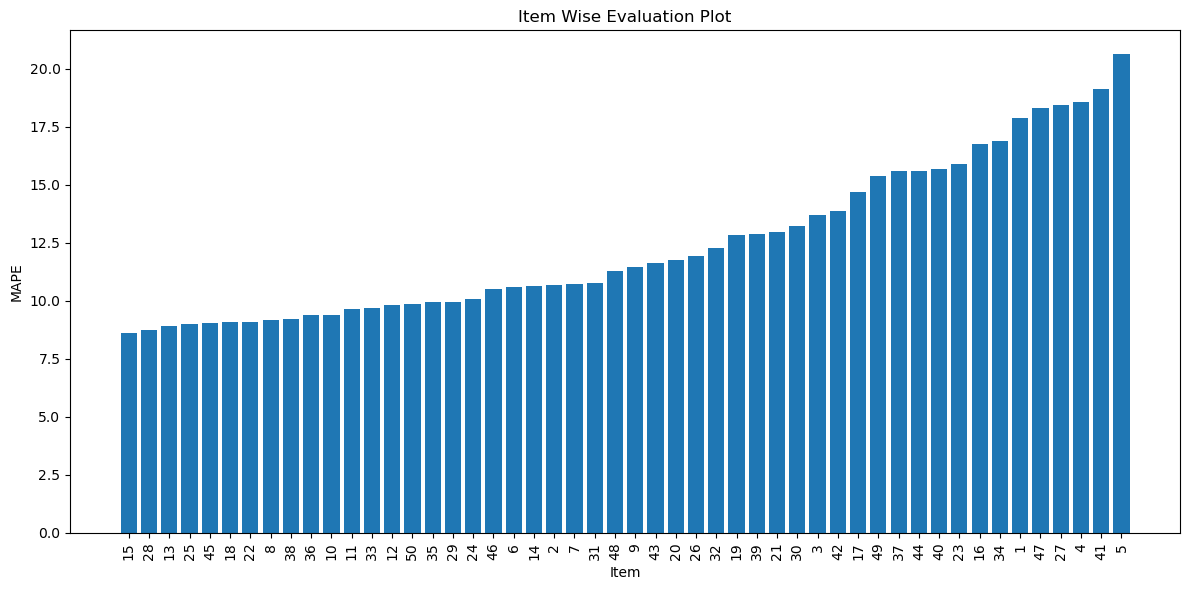

In [22]:
item_metrics_sorted = item_metrics.sort_values("MAPE")

plt.figure(figsize=(12,6))
plt.bar(item_metrics_sorted["item"].astype(str), item_metrics_sorted["MAPE"])

plt.xticks(rotation=90)
plt.title("Item Wise Evaluation Plot")
plt.xlabel("Item")
plt.ylabel("MAPE")

plt.tight_layout()
plt.savefig("../plots/comparision plots/Item_Wise_Evaluation_Plot.png")
plt.show()

In [23]:
item_metrics.tail()


,item,RMSE,MAPE,Observations
45,46,8.210664,10.527529,3650.0
46,47,5.074842,18.289698,3650.0
47,48,7.750147,11.287669,3650.0
48,49,5.797761,15.369520,3650.0
49,50,8.693280,9.853055,3650.0


In [24]:
print("Minimum RMSE : ")
item_metrics[item_metrics["RMSE"]==item_metrics["RMSE"].min()]

Minimum RMSE : 


,item,RMSE,MAPE,Observations
4,5,4.619732,20.621005,3650.0


In [25]:
print("Maximum RMSE : ")
item_metrics[item_metrics["RMSE"]==item_metrics["RMSE"].max()]

Maximum RMSE : 


,item,RMSE,MAPE,Observations
27,28,10.538486,8.763246,3650.0


In [26]:
print("Minimum MAPE : ")
item_metrics[item_metrics["MAPE"]==item_metrics["MAPE"].min()]

Minimum MAPE : 


,item,RMSE,MAPE,Observations
14,15,10.431173,8.609539,3650.0


In [27]:
print("Maximum MAPE : ")
item_metrics[item_metrics["MAPE"]==item_metrics["MAPE"].max()]

Maximum MAPE : 


,item,RMSE,MAPE,Observations
4,5,4.619732,20.621005,3650.0


In [28]:
item_metrics.describe()

,item,RMSE,MAPE,Observations
count,50.00000,50.000000,50.000000,50.0
mean,25.50000,7.721118,12.436141,3650.0
std,14.57738,1.747938,3.330782,0.0
min,1.00000,4.619732,8.609539,3650.0
25%,13.25000,6.093830,9.714864,3650.0
50%,25.50000,7.888702,11.362216,3650.0
75%,37.75000,9.174708,15.199316,3650.0
max,50.00000,10.538486,20.621005,3650.0


### 4. Store wise Evaluation

In [29]:
store_metrics = val_df.groupby("store").apply(
    lambda x: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(x["sales"], x["y_pred"])),
        "MAPE": x["abs_pct_error"].mean(),
        "Observations": len(x)
    })
).reset_index()

store_metrics.sort_values("RMSE")

C:\Users\devas\AppData\Local\Temp\ipykernel_8468\273825578.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_metrics = val_df.groupby("store").apply(


,store,RMSE,MAPE,Observations
6,7,6.501358,14.982470,18250.0
5,6,6.835164,14.030851,18250.0
4,5,6.855796,14.200936,18250.0
0,1,7.494451,12.881791,18250.0
8,9,8.090229,11.933076,18250.0
3,4,8.169002,12.013913,18250.0
9,10,8.361577,11.425411,18250.0
2,3,8.417768,11.287338,18250.0
7,8,8.861627,10.933036,18250.0
1,2,9.080477,10.672587,18250.0


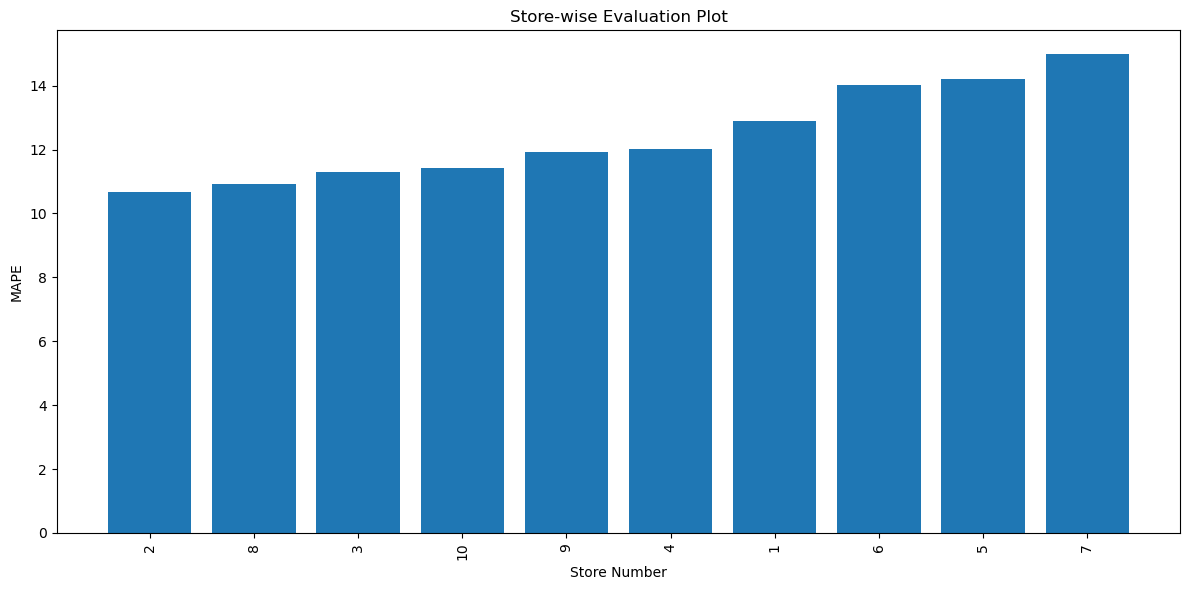

In [30]:
store_metrics_sorted = store_metrics.sort_values("MAPE")

plt.figure(figsize=(12,6))
plt.bar(store_metrics_sorted["store"].astype(str), store_metrics_sorted["MAPE"])

plt.xticks(rotation=90)
plt.title("Store-wise Evaluation Plot")
plt.xlabel("Store Number")
plt.ylabel("MAPE")

plt.tight_layout()
plt.savefig("../plots/comparision plots/Store_Wise_Evaluation_Plot.png")
plt.show()

In [31]:
print("Minimum RMSE : ")
store_metrics[store_metrics["RMSE"]==store_metrics["RMSE"].min()]

Minimum RMSE : 


,store,RMSE,MAPE,Observations
6,7,6.501358,14.98247,18250.0


In [32]:
store_metrics.describe()

,store,RMSE,MAPE,Observations
count,10.00000,10.000000,10.000000,10.0
mean,5.50000,7.866745,12.436141,18250.0
std,3.02765,0.897019,1.508573,0.0
min,1.00000,6.501358,10.672587,18250.0
25%,3.25000,7.015460,11.321856,18250.0
50%,5.50000,8.129616,11.973495,18250.0
75%,7.75000,8.403720,13.743586,18250.0
max,10.00000,9.080477,14.982470,18250.0


In [33]:
# Saving xgb_model predictions
import joblib
joblib.dump(val_preds, "../models/xgb_preds.joblib")
joblib.dump(y_val, "../models/y_val_actual.joblib")

['../models/y_val_actual.joblib']

### 5. Hyperparameters Tuning

In [ ]:

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best params:", search.best_params_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


### 5.1 Evaluation on Tuned Model

In [ ]:
val_preds_tuned = best_model.predict(X_val)

rmse_tuned = np.sqrt(mean_squared_error(y_val, val_preds_tuned))
mape_tuned = np.mean(np.abs((y_val - val_preds_tuned) / y_val)) * 100

print("Tuned RMSE:", rmse_tuned)
print("Tuned MAPE:", mape_tuned)

### 5.2 Interpretation (2)

Why Tuning Did not Help Much 

In structured demand data:

- Feature quality > hyperparameters
- When lag & rolling features are strong:
- XGBoost becomes very stable
- Gains from tuning are small (0–1%)

*Choosing the model that performs best on validation data — not the one that looks more complex.*

### 6. Final Model Training

In [ ]:
final_X = pd.concat([X_train, X_val])
final_y = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(final_X, final_y)


## Saving final model

In [ ]:
import joblib

joblib.dump(final_model, "../models/xgboost_model.pkl")

### 7. Predictions on Raw Test Data

In [ ]:
test_df = pd.read_csv("../data/raw/test.csv")
test_df

### *Same feature engineering that we have done on training data*

In [ ]:
# Converting object into datetime datatype and sorting them
test_df["date"] = pd.to_datetime(test_df["date"])
test_df.sort_values("date", inplace=True)
test_df

In [ ]:
test_df = test_df.sort_values(["store","item","date"])

In [ ]:
test_df = test_df.drop(columns=["id"])

In [ ]:
test_df.head()

In [ ]:
history = train_df.sort_values(["store","item","date"]).groupby(
    ["store","item"]
).tail(28)


In [ ]:
test_full = pd.concat([history, test_df], ignore_index=True)
test_full = test_full.sort_values(["store","item","date"])

In [ ]:
for lag in [1,7,14,28]:
    test_full[f"sales_lag_{lag}"] = (
        test_full.groupby(["store","item"])["sales"].shift(lag)
    )

test_full["rolling_mean_7"] = (
    test_full.groupby(["store","item"])["sales"]
    .shift(1).rolling(7).mean()
)

test_full["rolling_mean_14"] = (
    test_full.groupby(["store","item"])["sales"]
    .shift(1).rolling(14).mean()
)

test_full["rolling_mean_28"] = (
    test_full.groupby(["store","item"])["sales"]
    .shift(1).rolling(28).mean()
)

test_full["dayofweek"] = test_full["date"].dt.dayofweek
test_full["month"] = test_full["date"].dt.month
test_full["year"] = test_full["date"].dt.year


In [ ]:
test_features = test_full[test_full["sales"].isna() == False].copy()

In [ ]:
test_features = test_full.loc[test_full["date"].isin(test_df["date"])]

In [ ]:
FEATURES = [c for c in test_features.columns if c not in ["date","sales"]]

X_test = test_features[FEATURES]


In [ ]:
test_preds = final_model.predict(X_test)

In [ ]:
submission = pd.DataFrame({
    "date": test_df["date"],
    "store": test_df["store"],
    "item": test_df["item"],
    "predicted_sales": test_preds
})

submission.to_csv("../final_forecast/forecast.csv", index=False)

In [ ]:
!pip install lightgbm 

## ***Base line LightGBM***

In [ ]:
import lightgbm as lgbm
baselgbm = lgbm.LGBMRegressor(random_state=42, verbose=-1)
baselgbm.fit(X_train, y_train)

In [ ]:
y_baselgbm_pred = baselgbm.predict(X_val)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_val, y_baselgbm_pred))
print("RMSE:", rmse)

In [ ]:
#Business Metric
mape = np.mean(np.abs((y_val - val_preds) / y_val)) * 100
print("MAPE:", mape)

### Hyperparameter Tuning

In [ ]:
from scipy.stats import randint, uniform

In [ ]:
lgb_model = lgbm.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1
)

In [ ]:
param_dist = {
    'n_estimators': randint(200, 1200),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 150),
    'max_depth': randint(5, 20),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),   # bagging_fraction
    'colsample_bytree': uniform(0.6, 0.4),  # feature_fraction
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=30,  
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

In [ ]:
best_model_lgbm = random_search.best_estimator_

print("Best Params:", random_search.best_params_)
print("Best RMSE:", -random_search.best_score_)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
y_lgbm_pred = best_model_lgbm.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_lgbm_pred))
mape = mean_absolute_percentage_error(y_val, y_lgbm_pred)*100

print("RMSE:", rmse)
print("MAPE:", mape)

In [ ]:
joblib.dump(y_lgbm_pred, "../models/lgbm_preds.joblib")
joblib.dump(best_model_lgbm, "../models/lgbm_model.joblib")